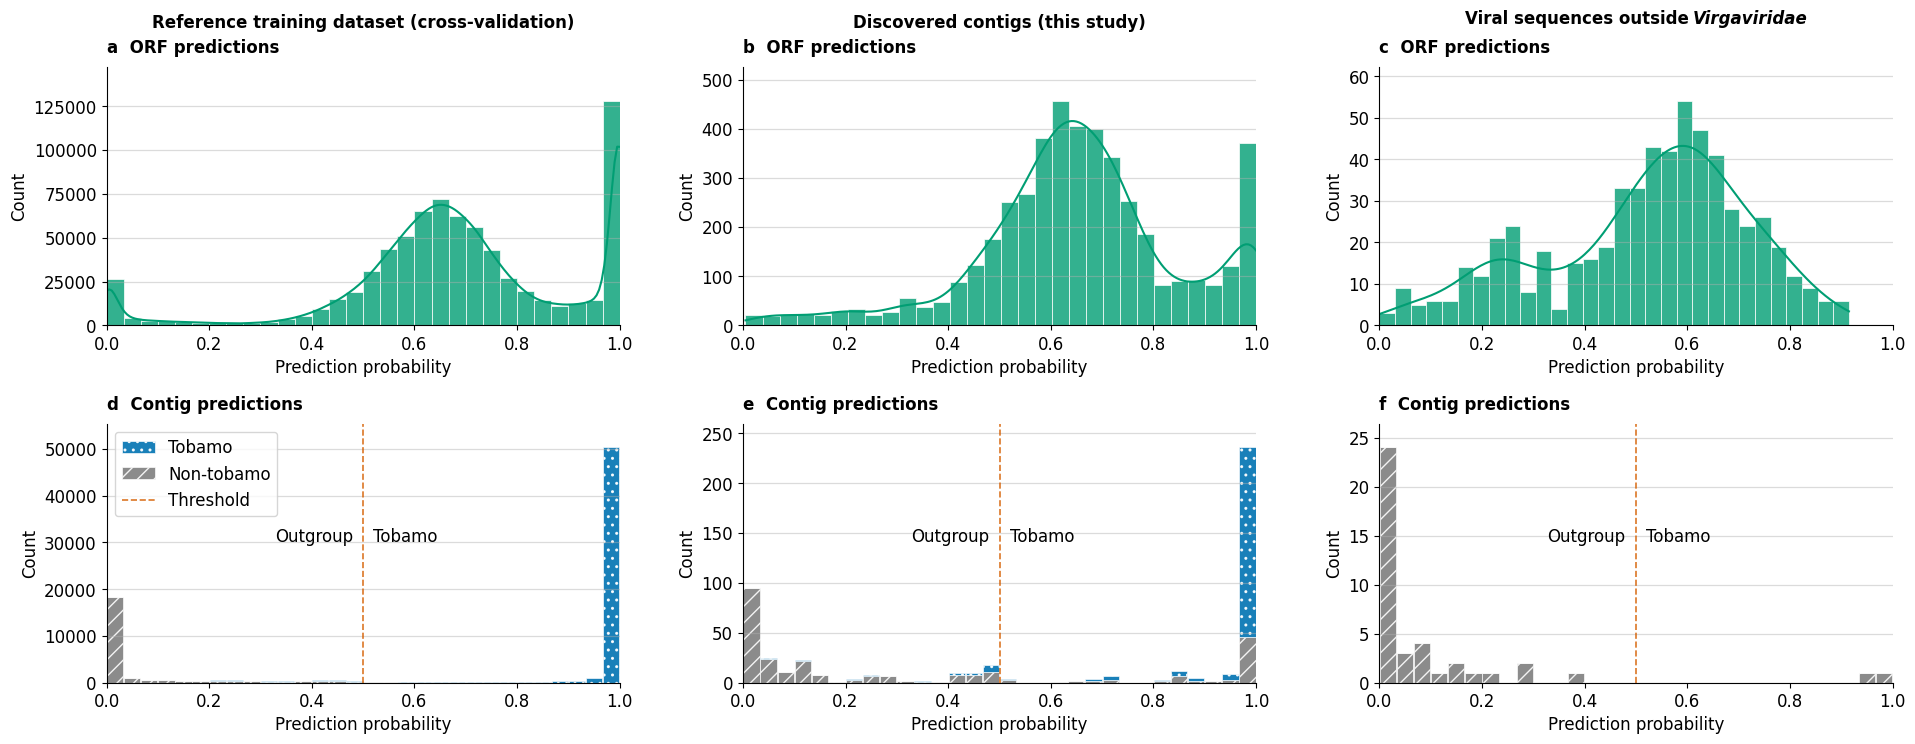

Saved: /home/tobamo/analize/project-tobamo/analysis/model/figures/supp_fig6_orf_predictions.png


In [3]:
# Final supplementary panel: 3 columns (datasets) x 2 rows (ORF/Contig)
# Subplots are labeled a-f.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# NOTE: Evaluation output filenames were renamed from stacking_* to binned_*; loaders below try binned first and fall back to legacy names.
# ------------------------------------------------------------------
# Paths and data loading (self-standing)
# ------------------------------------------------------------------
base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results'
evaluation_dir = results_dir / 'evaluation_results_fixed05'
figures_dir = base_dir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# Cross-validation data
cv_candidates = [
    evaluation_dir / 'binned_predictions_results.csv',
    evaluation_dir / 'stacking_predictions_results.csv',
]
histogram_cv_path = next((p for p in cv_candidates if p.exists()), None)
if histogram_cv_path is None:
    raise FileNotFoundError(f'No binned/stacking prediction file found in {evaluation_dir}')
histogram_cv = pd.read_csv(histogram_cv_path)
orf_histogram_cv = pd.read_csv(evaluation_dir / 'orf_predictions_results.csv')

# Random-sequence prediction data
orf_random_predictions = pd.read_csv(
    results_dir / 'random_seq/predictions/orf_predictions.csv',
    index_col=0,
)
contigs_random_predictions = pd.read_csv(
    results_dir / 'random_seq/predictions/contig_predictions.csv',
    index_col=0,
)

# Snakemake prediction data
snakemake_orf_predictions = pd.read_csv(results_dir / 'snakemake/predictions/orf_predictions.csv')
snakemake_contig_predictions = pd.read_csv(results_dir / 'snakemake/predictions/contig_predictions.csv')

# Ground truth + snakemake contigs
gt = pd.read_excel('/home/tobamo/analize/project-tobamo/analysis/data/domain_sci_input/ground_truth_final_added_categories.xlsx')
gt.columns = gt.columns.str.strip()
df_gt = pd.merge(gt, snakemake_contig_predictions, on='contig_name', how='inner').copy()
df_gt['category'] = df_gt['category'].astype(str)
df_gt['prob_1'] = pd.to_numeric(df_gt['prob_1'], errors='coerce')
tobamo_categories = ['tob1', 'tob2', 'tob3']
df_gt['gt_binary'] = df_gt['category'].isin(tobamo_categories).astype(int)
df_gt = df_gt.dropna(subset=['prob_1'])

# ------------------------------------------------------------------
# Shared style/config
# Edit these values to quickly adjust typography
# ------------------------------------------------------------------
FS_COL_TITLE = 12
FS_SUBTITLE = 12
FS_LABEL = 12
FS_TICK = 12
FS_LEGEND = 12
FS_TEXT = 12

# Add extra vertical separation between column-level title and subplot titles.
COL_TITLE_PAD = 28
ROW_TITLE_PAD = 10

plt.style.use('default')
plt.rcParams.update({
    'font.size': FS_LABEL,
    'axes.titlesize': FS_COL_TITLE,
    'axes.labelsize': FS_LABEL,
    'xtick.labelsize': FS_TICK,
    'ytick.labelsize': FS_TICK,
    'legend.fontsize': FS_LEGEND,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
plt.rcParams['mathtext.fontset'] = 'stix'

# Colorblind-friendly palette (same family as main_fig)
colors = {
    'orf': '#009E73',
    'tobamo': '#0072B2',
    'non_tobamo': '#7F7F7F',
    'threshold': '#D55E00',
}


def style_axis(ax):
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', which='major', labelsize=FS_TICK)


def add_mixed_column_title(ax, prefix, italic_word, fontsize, pad, gap_px=4.0):
    fig = ax.figure

    temp_prefix = ax.text(
        0,
        0,
        prefix,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=fontsize,
        fontweight='bold',
        alpha=0.0,
    )
    temp_word = ax.text(
        0,
        0,
        italic_word,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=fontsize,
        fontweight='bold',
        fontstyle='italic',
        alpha=0.0,
    )

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    prefix_width = temp_prefix.get_window_extent(renderer=renderer).width
    word_width = temp_word.get_window_extent(renderer=renderer).width

    temp_prefix.remove()
    temp_word.remove()

    axes_bbox = ax.get_window_extent(renderer=renderer)
    total_width = prefix_width + gap_px + word_width
    x_left = 0.5 - (total_width / axes_bbox.width) / 2.0
    y = 1.0 + ((pad * fig.dpi / 72.0) / axes_bbox.height)

    ax.text(
        x_left,
        y,
        prefix,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=fontsize,
        fontweight='bold',
        clip_on=False,
    )
    ax.text(
        x_left + ((prefix_width + gap_px) / axes_bbox.width),
        y,
        italic_word,
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=fontsize,
        fontweight='bold',
        fontstyle='italic',
        clip_on=False,
    )


def plot_orf_panel(ax, data, letter):
    local = data.copy()
    local['prob_1'] = pd.to_numeric(local['prob_1'], errors='coerce')
    local = local.dropna(subset=['prob_1'])

    sns.histplot(
        data=local,
        x='prob_1',
        bins=30,
        kde=True,
        color=colors['orf'],
        alpha=0.8,
        ax=ax,
        edgecolor='white',
        linewidth=0.5,
    )
    max_height = ax.get_ylim()[1]
    ax.set_ylim(0, max(1.0, max_height * 1.1))
    ax.set_title(
        f'{letter}  ORF predictions',
        fontsize=FS_SUBTITLE,
        fontweight='bold',
        loc='left',
        pad=ROW_TITLE_PAD,
    )
    ax.set_xlabel('Prediction probability', fontsize=FS_LABEL)
    ax.set_ylabel('Count', fontsize=FS_LABEL)
    ax.grid(axis='y', alpha=0.45, linewidth=0.9)
    style_axis(ax)


def plot_contig_panel(ax, contig_df, truth_col, letter, show_legend=False):
    eval_df = contig_df.copy()
    eval_df['prob_1'] = pd.to_numeric(eval_df['prob_1'], errors='coerce')
    eval_df[truth_col] = pd.to_numeric(eval_df[truth_col], errors='coerce').fillna(0).astype(int)
    eval_df = eval_df.dropna(subset=['prob_1'])

    bins = np.linspace(0, 1, 31)
    tob_vals = eval_df.loc[eval_df[truth_col] == 1, 'prob_1'].astype(float)
    non_vals = eval_df.loc[eval_df[truth_col] == 0, 'prob_1'].astype(float)

    tob_hist, _ = np.histogram(tob_vals, bins=bins)
    non_hist, _ = np.histogram(non_vals, bins=bins)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_width = (bins[1] - bins[0]) * 0.95

    ax.bar(
        bin_centers,
        non_hist,
        width=bin_width,
        color=colors['non_tobamo'],
        alpha=0.9,
        hatch='//',
        edgecolor='white',
        linewidth=0.5,
        label='Non-tobamo',
    )
    ax.bar(
        bin_centers,
        tob_hist,
        width=bin_width,
        bottom=non_hist,
        color=colors['tobamo'],
        alpha=0.9,
        hatch='..',
        edgecolor='white',
        linewidth=0.5,
        label='Tobamo',
    )

    max_height = max(1, np.max(non_hist + tob_hist))
    ax.set_ylim(0, max_height * 1.1)
    ax.set_title(
        f'{letter}  Contig predictions',
        fontsize=FS_SUBTITLE,
        fontweight='bold',
        loc='left',
        pad=ROW_TITLE_PAD,
    )
    ax.set_xlabel('Prediction probability', fontsize=FS_LABEL)
    ax.set_ylabel('Count', fontsize=FS_LABEL)
    ax.grid(axis='y', alpha=0.45, linewidth=0.9)
    ax.axvline(
        x=0.5,
        color=colors['threshold'],
        linestyle='--',
        linewidth=1.2,
        alpha=0.85,
        label='Threshold',
    )
    ax.text(0.52, max_height * 0.6, 'Tobamo', fontsize=FS_TEXT)
    ax.text(0.48, max_height * 0.6, 'Outgroup', fontsize=FS_TEXT, ha='right')

    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        lookup = {label: handle for handle, label in zip(handles, labels)}
        order = ['Tobamo', 'Non-tobamo', 'Threshold']
        legend_handles = [lookup[label] for label in order if label in lookup]
        legend_labels = [label for label in order if label in lookup]
        if legend_handles:
            ax.legend(legend_handles, legend_labels, loc='upper left', fontsize=FS_LEGEND, frameon=True)

    style_axis(ax)


# ------------------------------------------------------------------
# Figure layout: 3 columns x 2 rows
# ------------------------------------------------------------------
fig = plt.figure(figsize=(19, 7.8))
gs_outer = fig.add_gridspec(1, 3, wspace=0.24)

column_titles = [
    'Reference training dataset (cross-validation)',
    'Discovered contigs (this study)',
    'Viral sequences outside',
]

# Column 1: Reference training dataset (cross-validation)
ax_col1 = fig.add_subplot(gs_outer[0, 0])
gs_col1 = ax_col1.get_subplotspec().subgridspec(2, 1, hspace=0.38)
ax_a = fig.add_subplot(gs_col1[0])
ax_d = fig.add_subplot(gs_col1[1])
ax_col1.set_frame_on(False)
ax_col1.set_xticks([])
ax_col1.set_yticks([])
ax_col1.set_title(column_titles[0], fontsize=FS_COL_TITLE, fontweight='bold', pad=COL_TITLE_PAD)

plot_orf_panel(ax_a, orf_histogram_cv, 'a')
plot_contig_panel(ax_d, histogram_cv, 'ground_truth', 'd', show_legend=True)

# Column 2: Discovered contigs (this study)
ax_col2 = fig.add_subplot(gs_outer[0, 1])
gs_col2 = ax_col2.get_subplotspec().subgridspec(2, 1, hspace=0.38)
ax_b = fig.add_subplot(gs_col2[0])
ax_e = fig.add_subplot(gs_col2[1])
ax_col2.set_frame_on(False)
ax_col2.set_xticks([])
ax_col2.set_yticks([])
ax_col2.set_title(column_titles[1], fontsize=FS_COL_TITLE, fontweight='bold', pad=COL_TITLE_PAD)

plot_orf_panel(ax_b, snakemake_orf_predictions, 'b')
plot_contig_panel(ax_e, df_gt, 'gt_binary', 'e', show_legend=False)

# Column 3: Viral sequences outside Virgaviridae
ax_col3 = fig.add_subplot(gs_outer[0, 2])
gs_col3 = ax_col3.get_subplotspec().subgridspec(2, 1, hspace=0.38)
ax_c = fig.add_subplot(gs_col3[0])
ax_f = fig.add_subplot(gs_col3[1])
ax_col3.set_frame_on(False)
ax_col3.set_xticks([])
ax_col3.set_yticks([])

plot_orf_panel(ax_c, orf_random_predictions, 'c')
random_non_tob = contigs_random_predictions.copy()
random_non_tob['gt_binary'] = 0
plot_contig_panel(ax_f, random_non_tob, 'gt_binary', 'f', show_legend=False)

plt.subplots_adjust(right=0.985, left=0.045, bottom=0.09, top=0.88)
add_mixed_column_title(ax_col3, column_titles[2], 'Virgaviridae', FS_COL_TITLE, COL_TITLE_PAD)
out_path = figures_dir / 'supp_fig6_orf_predictions.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()

print(f'Saved: {out_path}')